In [ ]:
from collections import Counter
from pathlib import Path

folder = Path("dataset/normal")

extensions = Counter(
    p.suffix.lower() or "<no extension>"
    for p in folder.iterdir()
    if p.is_file()
)

extensions

Datele de ieșire de afișat au fost trunchiate la ultimele 5000 linii.
path: dataset/malicious/RFP_PF_29936.wav; label:1
path: dataset/malicious/RFP_PF_30621.wav; label:1
path: dataset/malicious/34.mp3; label:1
path: dataset/malicious/RFP_PF_04243.wav; label:1
path: dataset/malicious/RFP_PF_29181.wav; label:1
path: dataset/malicious/RFP_PF_05449.wav; label:1
path: dataset/malicious/RFP_PF_03703.wav; label:1
path: dataset/malicious/RFP_PF_00368.wav; label:1
path: dataset/malicious/RFP_PF_29137.wav; label:1
path: dataset/malicious/651829_normalized.wav; label:1
path: dataset/malicious/RFP_PF_27772.wav; label:1
path: dataset/malicious/1609960554.16654_in_Range_Telecom_Robocall__StudentLoan-FederalSuspension_normalized.wav; label:1
path: dataset/malicious/525147_normalized.wav; label:1
path: dataset/malicious/RFP_PF_02020.wav; label:1
path: dataset/malicious/RFP_PF_03866.wav; label:1
path: dataset/malicious/815820_normalized.wav; label:1
path: dataset/malicious/RFP_PF_00632.wav; label:1
pat

/tmp/ipykernel_1931/2041701204.py:23: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  duration_sec = librosa.get_duration(path=path)


path: dataset/malicious/RFP_PF_04010.wav; label:1
path: dataset/malicious/RFP_PF_04105.wav; label:1
path: dataset/malicious/RFP_PF_31201.wav; label:1
path: dataset/malicious/1036336_normalized.wav; label:1
path: dataset/malicious/RFP_PF_04849.wav; label:1
path: dataset/malicious/649854_normalized.wav; label:1
path: dataset/malicious/RFP_PF_27765.wav; label:1
path: dataset/malicious/RFP_PF_01748.wav; label:1
path: dataset/malicious/RFP_PF_03291.wav; label:1
path: dataset/malicious/93988_normalized.wav; label:1
path: dataset/malicious/1294790_normalized.wav; label:1
path: dataset/malicious/RFP_PF_30704.wav; label:1
path: dataset/malicious/1315929_normalized.wav; label:1
path: dataset/malicious/RFP_PF_27865.wav; label:1
path: dataset/malicious/RFP_PF_30477.wav; label:1
path: dataset/malicious/RFP_PF_01120.wav; label:1
path: dataset/malicious/RFP_PF_01994.wav; label:1
path: dataset/malicious/1153267_normalized.wav; label:1
path: dataset/malicious/RFP_PF_30622.wav; label:1
path: dataset/mal

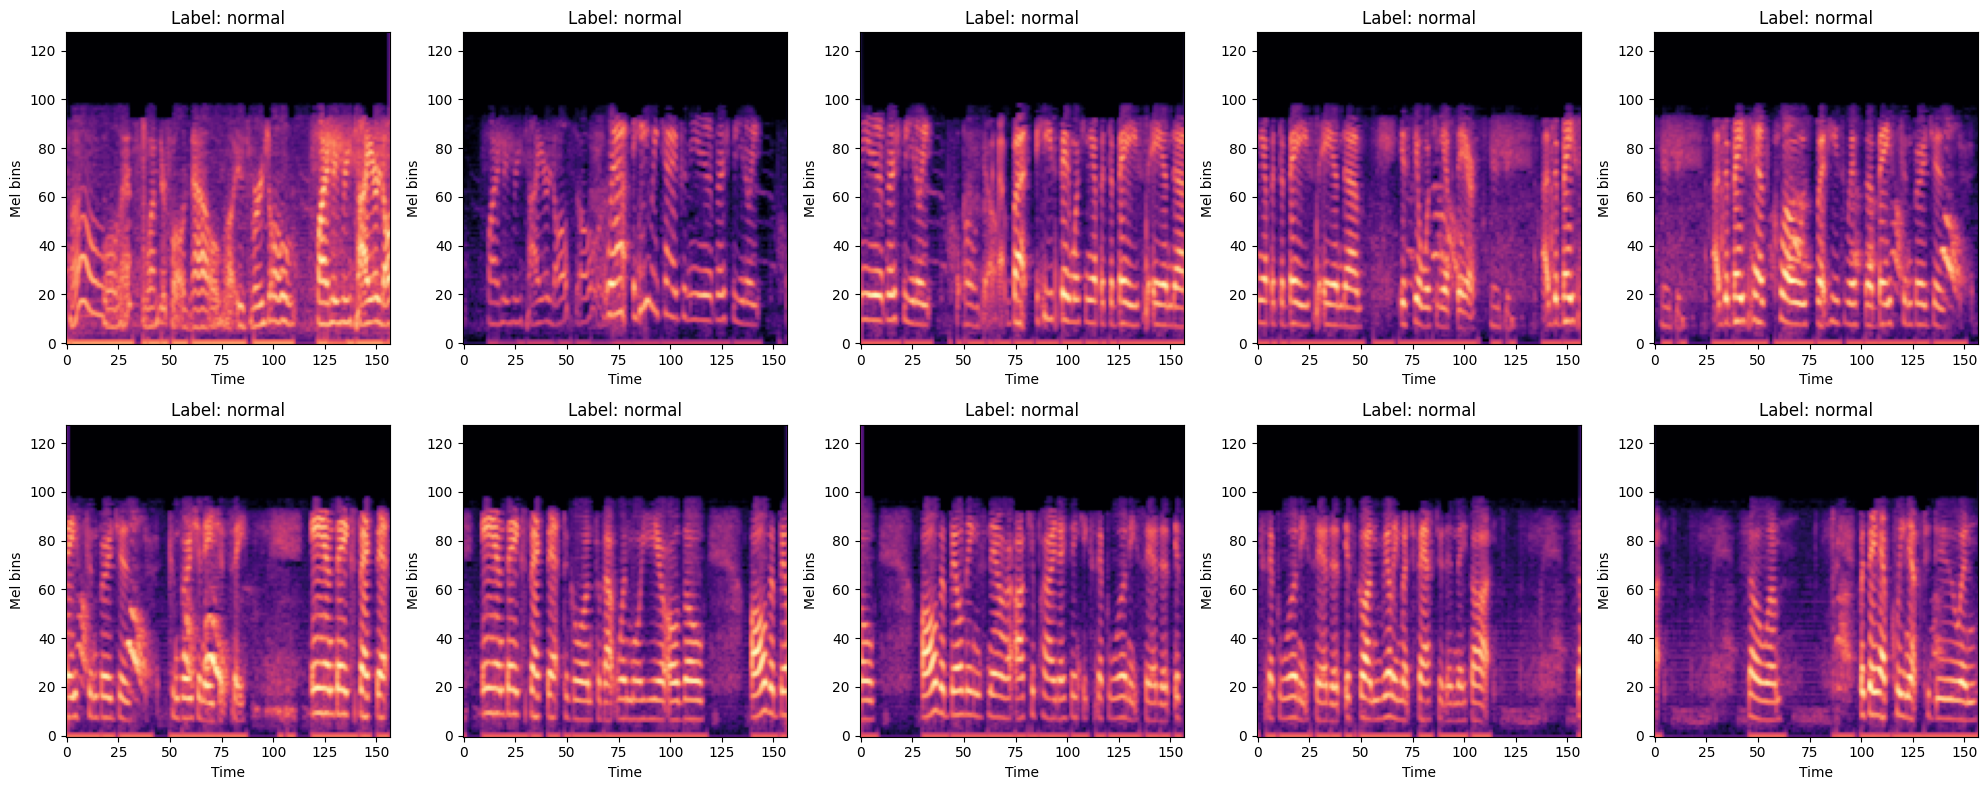

In [5]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class Spectrogram(Dataset):
    def __init__(self, base_path, sr=16000, window_size=5.0, min_overlap=1.5): #sr=sample rate
        self.sr = sr
        self.window_size = int(window_size * sr) #we convert time into array indices
        self.min_overlap = int(min_overlap * sr)
        self.samples = []

        for label, category in enumerate(['normal', 'malicious']):
            dir_path = os.path.join(base_path, category)
            for f in os.listdir(dir_path):
                if f.lower().endswith(('.wav', '.mp3')):
                    path = os.path.join(dir_path, f)
                    try:
                        duration_sec = librosa.get_duration(path=path)
                    except Exception as e:
                        print(f"Warning: Could not process file {path}. Skipping. Error: {e}")
                        continue
                    audio = int(sr*duration_sec)

                    # Logic: Calculate step based on 8.5s rule
                    if audio < int(8.5 * sr) and audio >= self.window_size:
                        step = (audio - self.window_size) // 1
                        if step==0: step=1
                    else:
                        step = self.window_size - self.min_overlap

                    # Sliding Window Loop
                    for start in range(0, audio - self.window_size + 1, step):
                        self.samples.append((path, start, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, start, label = self.samples[idx]
        audio, _ = librosa.load(path, sr=self.sr, offset=start/self.sr, duration=5.0)

        # Spectrogram conversion
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=self.sr, n_mels=128)
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)

        return torch.tensor(log_mel).unsqueeze(0), torch.tensor(label)
p=Spectrogram('dataset')

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i in range(10):
    mel, label = p[i]          # mel: (1, 128, T)
    mel = mel.squeeze(0)       # (128, T)

    axes[i].imshow(
        mel,
        origin='lower',
        aspect='auto',
        cmap='magma'
    )

    axes[i].set_title(f"Label: {'malicious' if label==1 else 'normal'}")
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Mel bins")

plt.tight_layout()
plt.show()

In [ ]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Block 1: Feature Extraction
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )

        # Block 2: The "Bulletproof" Funnel
        # This forces the spatial dimensions down to 1x1, regardless of input length.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Block 3: Classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 128), # It's 32 because the last Conv2d output 32 channels
            nn.ReLU(),
            nn.Dropout(0.5), # Added dropout to prevent overfitting
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x



In [6]:
!git add .
!git commit -m 'plotted spectograms'

Refresh index: 100% (249/249), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   MinIO_Process.ipynb
	modified:   Spectograms.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
# Initialization and Splitting
dataset = Spectrogram('dataset')
train_sz = int(0.8 * len(dataset))
val_sz = int(0.1 * len(dataset))
test_sz = len(dataset) - train_sz - val_sz

train_db, val_db, test_db = random_split(dataset, [train_sz, val_sz, test_sz])

train_loader = DataLoader(train_db, batch_size=16, shuffle=True)
model = SimpleCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
if device is "cpu" :
  print("ERROR! Not using GPU")
  exit(0)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


epochs = 10 # How many times to loop over the whole dataset

print(f"Starting training on {device}...")

for epoch in range(epochs):
    model.train() # Put model in training mode
    running_loss = 0.0

    for batch_idx, (spectrograms, labels) in enumerate(train_loader):
        # Move data to the same device as the model
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        # 1. Zero the gradients (clear old memory)
        optimizer.zero_grad()

        # 2. Forward pass (make a prediction)
        outputs = model(spectrograms)

        # 3. Calculate the error
        loss = criterion(outputs, labels)

        # 4. Backward pass (calculate how to fix the error)
        loss.backward()

        # 5. Update the weights
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# NOW you save it, after it has learned
torch.save(model.state_dict(), 'malicious_call_detector_trained.pth')
print("Training complete and model saved.")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd drive/MyDrive/MaliciousCallDetection/


/content/drive/MyDrive/MaliciousCallDetection


In [15]:
!git commit -m 'Modified MinIO_Process to work in google colab folder hierarchy. Also 16kHz data is in drive now'

[main a3c1f38] Modified MinIO_Process to work in google colab folder hierarchy. Also 16kHz data is in drive now
 2 files changed, 2 insertions(+), 2 deletions(-)


In [14]:
!git config --global user.email "marinescudragos2014@gmail.com"
!git config --global user.name "Marinescu Dragos"

In [16]:
!git push

fatal: could not read Username for 'https://github.com': No such device or address
